In [14]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a, b를 더한다"""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a, b를 곱한다"""
    return a * b

In [15]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

In [16]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply]

llm_with_tools = llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [17]:
ai_message = llm_with_tools.invoke('3 더하기 5는?')

In [18]:
ai_message

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 83, 'total_tokens': 100, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_c7519a35cf', 'id': 'chatcmpl-DfKYdcb2wZFtG6IlvvKpsJQV1DJad', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e2555-d7fd-7510-b05d-21d513b3ab50-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 5}, 'id': 'call_MQBVJl0HWMk5UNqhFqHxYwKp', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 83, 'output_tokens': 17, 'total_tokens': 100, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 83, 'total_tokens': 100, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_c7519a35cf', 'id': 'chatcmpl-DfK2CetnQOrCP1ALUAA30280kbkJq', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e2537-25fe-7222-a077-3ac04894a996-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 5}, 'id': 'call_GLRYI50R2hv1icmmCa28i8VL', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 83, 'output_tokens': 17, 'total_tokens': 100, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [19]:
"""LangGraph 1.x 버전에서 Runtime이 없어 에러"""
tool_node.invoke({'messages': [ai_message]})

ValueError: Missing required config key 'N/A' for 'tools'.

In [35]:
from langgraph.runtime import Runtime

tool_node.invoke({'messages': [ai_message]}, runtime = Runtime())

{'messages': [ToolMessage(content='8', name='add', tool_call_id='call_MQBVJl0HWMk5UNqhFqHxYwKp')]}

In [20]:
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)

In [21]:
def agent(state: MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [22]:
def should_continue(state: MessagesState):
    """AIMessage.tool_calls 여부로 tool 호출 여부 결정"""
    messages = state['messages']
    last_message = messages[-1]
    
    if last_message.tool_calls:
        return 'tools'
    return 'end'

In [23]:
"""NODE 추가"""
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)

In [24]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    {
        'tools': 'tools',
        'end': END
    }
)
graph_builder.add_edge('tools', 'agent')

In [25]:
graph = graph_builder.compile()

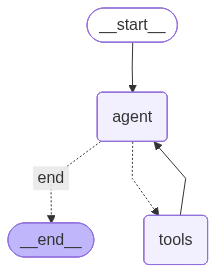

In [26]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [33]:
from langchain_core.messages import HumanMessage

for chunk in graph.stream({'messages': [HumanMessage('3에다 5를 더하고 거기에 8을 곱하면?')]}, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

3에다 5를 더하고 거기에 8을 곱하면?
================================== Ai Message ==================================
Tool Calls:
  add (call_C7frh1ntEMXoPnV6kj5UyooF)
 Call ID: call_C7frh1ntEMXoPnV6kj5UyooF
  Args:
    a: 3
    b: 5
  multiply (call_5gAq1aSxyWGeCEp4aIUSlFNK)
 Call ID: call_5gAq1aSxyWGeCEp4aIUSlFNK
  Args:
    a: 8
    b: 8
================================= Tool Message =================================
Name: multiply

64
================================== Ai Message ==================================
Tool Calls:
  multiply (call_n609rvAJ4H83X02KQ5CsY34P)
 Call ID: call_n609rvAJ4H83X02KQ5CsY34P
  Args:
    a: 8
    b: 8
================================= Tool Message =================================
Name: multiply

64
================================== Ai Message ==================================

3에 5를 더하면 8이 되고, 여기에 8을 곱하면 64가 됩니다.
